# Análisis de series temporales
En el presente cuadernillo se halla la réplica del modelo de análisis de series temporales, hecho en `Python`, para el caso de análisis de este TFG. En este cuadernillo solo se realizará una réplica del modelo usado en el cuadernillo <a href="Análisis temporal en R.ipynb" target="_blank"><code>Análisis temporal en R.ipynb</code></a> y la comparación sintáctica para usarse como base para el uso del paquete `pyrcore` en la última parte del TFG. Se utiliza `auto_arima()`. El modelo no tiene por qué arrojar un resultado correcto, sino establecer el comportamiento habitual del modelo en Python.

**Caso de estudio**: Análisis temporal de las series de producción de gas de esquisto en varios sitios de EEUU para el periodo enero de 2000 a agosto de 2022 (2000.01-2022.08).

In [1]:
# Librerías
try:
    import pandas as pd
except:
    %pip install pandas
    import pandas as pd
try:
    import matplotlib.pyplot as plt
except:
    %pip install matplotlib
    import matplotlib.pyplot as plt
try:
    from pmdarima.arima import ARIMA,auto_arima
except:
    %pip install pmdarima
    from pmdarima.arima import ARIMA,auto_arima
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
except:
    %pip install statsmodels
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

## Importar datos

In [2]:
# Importar datos
gas=pd.read_excel("..\\datasets\\data_shale_gas_010822.xlsx",header=1)

# Previsualizar DataFrame
gas.head()

,Date,Barnett (TX),Haynesville (LA & TX),"Marcellus (PA, WV, OH & NY)",Permian (TX & NM),"Utica (OH, PA & WV)",Woodford (OK),Bakken (ND & MT),Niobrara-Codell (CO & WY),Mississippian (OK),Unnamed: 10
0,2000-01-01,0.133710,0.141004,0.000845,0.632070,0.000295,0.009290,0.013501,0.257174,0.687040,Units:
1,2000-02-01,0.139530,0.140833,0.000845,0.642394,0.000295,0.008526,0.013116,0.258500,0.694208,bcf per day
2,2000-03-01,0.150565,0.140300,0.000845,0.665302,0.000295,0.008626,0.012867,0.258599,0.704223,NaN
3,2000-04-01,0.159842,0.142965,0.000844,0.680048,0.000295,0.008810,0.013325,0.253798,0.689270,NaN
4,2000-05-01,0.163962,0.143643,0.000843,0.701509,0.000295,0.008716,0.012843,0.253023,0.724272,NaN


In [ ]:
# Seleccionar la serie Haynesville (LA & TX)
gas=gas.iloc[:,2]
gas.head()

2000-01-01    0.141004
2000-02-01    0.140833
2000-03-01    0.140300
2000-04-01    0.142965
2000-05-01    0.143643
dtype: float64

## Análisis clásico

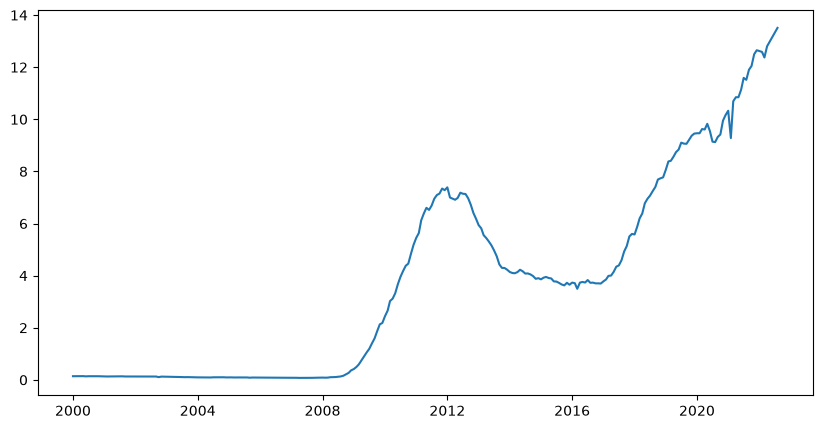

In [4]:
# Representar la serie
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(gas);

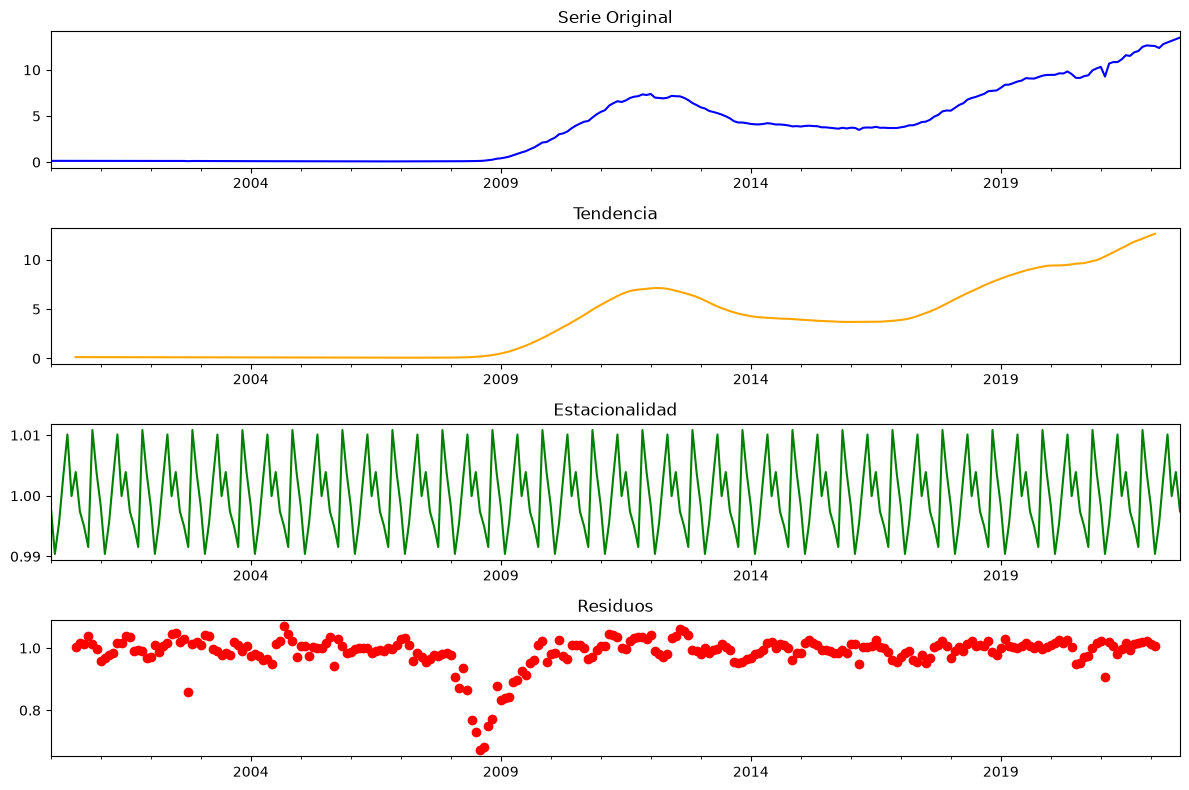

In [5]:
# Descomponer la serie
resultado=seasonal_decompose(gas,model="multiplicative")
# Visualizar los componentes
fig,ax=plt.subplots(4,1,figsize=(12,8))
resultado.observed.plot(ax=ax[0],color="blue")
ax[0].set_title("Serie Original")
resultado.trend.plot(ax=ax[1],color="orange")
ax[1].set_title("Tendencia")
resultado.seasonal.plot(ax=ax[2],color="green")
ax[2].set_title("Estacionalidad")
resultado.resid.plot(ax=ax[3],color="red",marker="o",linestyle="none")
ax[3].set_title("Residuos")
# Mostrar gráfico
plt.tight_layout();

* Se intuye una tendencia aproximadamente cuadrática, por lo que habrá que aplicar dos diferencias lineales.
* Los **Í**ndices de **V**ariación **E**stacional (**IVE**s) son muy cercanos a 1, por lo que la variación estacional no es lo bastante significativa como para requerir transformaciones estacionales.

A continuación se realiza una comprobación automatizada.

In [6]:
# Comprobación de transformaciones
from pmdarima.arima.utils import ndiffs,nsdiffs
ndiffs(gas),nsdiffs(gas,12)

(2, 0)

Efectivamente, llegamos a la conclusión de que solo hay que aplicar dos diferencias lineales.

## Separación y transformaciones

In [7]:
# Separación en conjuntos de train y test
train=gas[:-5]
test=gas[-5:]
train,test

(2000-01-01     0.141004
 2000-02-01     0.140833
 2000-03-01     0.140300
 2000-04-01     0.142965
 2000-05-01     0.143643
                 ...    
 2021-11-01    12.498925
 2021-12-01    12.651080
 2022-01-01    12.620861
 2022-02-01    12.585889
 2022-03-01    12.373100
 Length: 267, dtype: float64,
 2022-04-01    12.802725
 2022-05-01    12.975754
 2022-06-01    13.151122
 2022-07-01    13.328860
 2022-08-01    13.509000
 dtype: float64)

In [8]:
# Aplicar diferencias lineales
train=train.diff(2)
train

2000-01-01         NaN
2000-02-01         NaN
2000-03-01   -0.000705
2000-04-01    0.002133
2000-05-01    0.003344
                ...   
2021-11-01    0.595789
2021-12-01    0.606205
2022-01-01    0.121936
2022-02-01   -0.065192
2022-03-01   -0.247761
Length: 267, dtype: float64

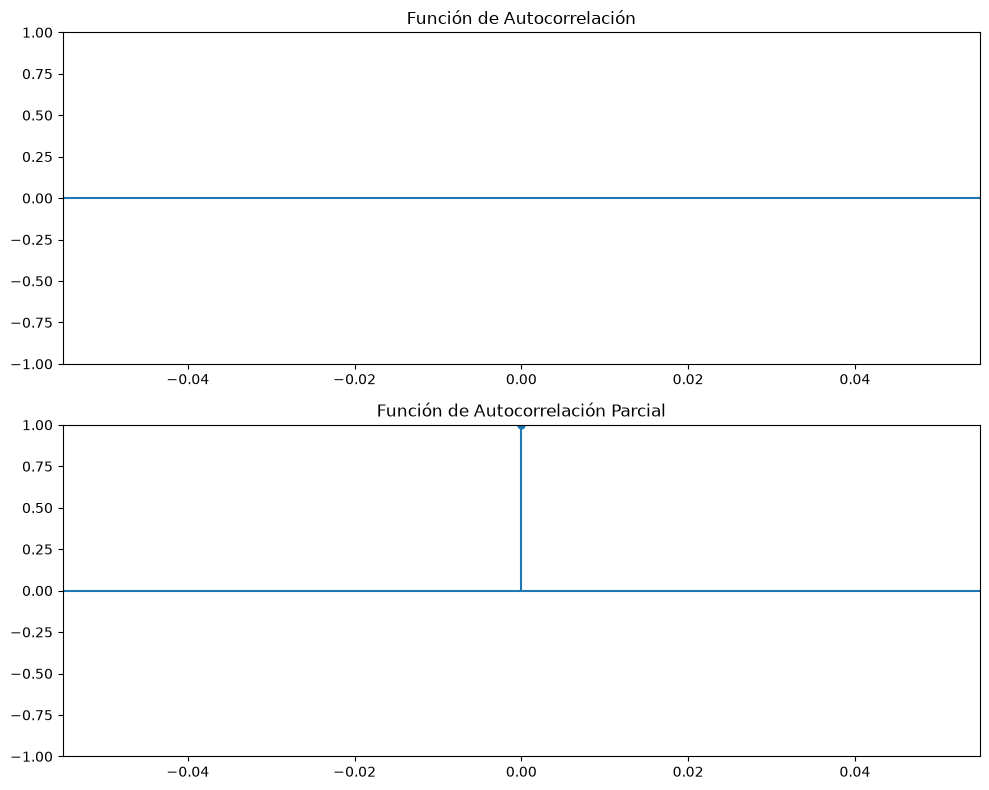

In [9]:
# Declarar elementos del gráfico
fig,ax=plt.subplots(2, 1, figsize=(10, 8))

# Correlograma de Autocorrelación (ACF)
plot_acf(train,ax=ax[0],lags=40)
ax[0].set_title("Función de Autocorrelación")

# Correlograma de Autocorrelación Parcial (PACF)
plot_pacf(train,ax=ax[1],lags=40)
ax[1].set_title("Función de Autocorrelación Parcial")

plt.tight_layout();

* **AR(p=1)**
* **Dos diferencias lineales (d=2)**
* **MA(q=2)**

Por tanto, el modelo es un **ARIMA(1,2,2)** (`p = 1`, `d = 2`, `q = 2`).

## Ajuste del modelo

In [10]:
# Se ajusta el modelo
modelo=ARIMA((1,2,2),m=12).fit(gas[:train.index[-1]]) # Se reconstruye el conjunto de entrenamiento
pred=modelo.predict(5)
pred

c:\Users\ricar\Desktop\Personal\Python\UFV\TFG\.TFG\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ricar\Desktop\Personal\Python\UFV\TFG\.TFG\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\ricar\Desktop\Personal\Python\UFV\TFG\.TFG\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['m']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


2022-04-01    12.436387
2022-05-01    12.538041
2022-06-01    12.605568
2022-07-01    12.704594
2022-08-01    12.775711
Freq: MS, dtype: float64

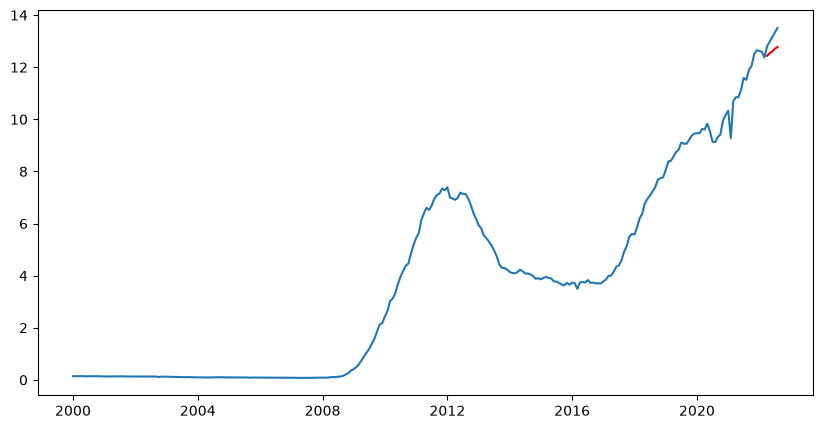

In [11]:
# Representar predicción
plt.figure(figsize=(10,5))
plt.plot(gas)
plt.plot(pred,color="red");

El análisis ha terminado y el modelo ajusta correctamente.